In [88]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score 
from sklearn.preprocessing import PolynomialFeatures


# Load data


In [ ]:
# Load data
df = pd.read_csv("global_climate_energy_2020_2024.csv")


In [117]:
TARGET_COL = "energy_consumption"
df.head()

,date,country,avg_temperature,humidity,co2_emission,energy_consumption,renewable_share,urban_population,industrial_activity_index,energy_price
0,2020-01-01,Germany,28.29,31.08,212.63,11348.75,14.42,76.39,51.22,83.93
1,2020-01-02,Germany,28.38,37.94,606.05,4166.64,5.63,86.26,78.27,110.40
2,2020-01-03,Germany,28.74,57.67,268.72,4503.80,14.20,75.92,48.96,173.58
3,2020-01-04,Germany,26.66,51.34,167.32,3259.13,13.84,63.15,97.42,89.13
4,2020-01-05,Germany,26.81,65.38,393.89,7023.72,6.93,76.02,81.89,40.60


In [90]:
# Drop Timestamp column (not needed for model)

print("Columns before preprocessing:", df.columns.tolist())

# Identify categorical and numerical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Remove target from numerical columns
if TARGET_COL in numerical_cols:
    numerical_cols.remove(TARGET_COL)

print(f"Categorical columns: {categorical_cols}")
print(f"Numerical columns: {numerical_cols}")


Columns before preprocessing: ['Timestamp', 'Temperature', 'Humidity', 'SquareFootage', 'Occupancy', 'HVACUsage', 'LightingUsage', 'RenewableEnergy', 'DayOfWeek', 'Holiday', 'EnergyConsumption']
Categorical columns: ['Timestamp', 'HVACUsage', 'LightingUsage', 'DayOfWeek', 'Holiday']
Numerical columns: ['Temperature', 'Humidity', 'SquareFootage', 'Occupancy', 'RenewableEnergy']


# One-hot encoding

In [91]:
categorical_cols.remove("DayOfWeek")

In [92]:
print("catgerical columns after removing DayOfWeek:", categorical_cols)

catgerical columns after removing DayOfWeek: ['Timestamp', 'HVACUsage', 'LightingUsage', 'Holiday']


# Preprocess the dayofweek  feature

In [93]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")
df["day_of_week"] = df["Timestamp"].dt.dayofweek
df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

In [94]:
df.drop(columns=["Timestamp", "day_of_week", "DayOfWeek"], inplace=True)


In [95]:
df.head()

,Temperature,Humidity,SquareFootage,Occupancy,HVACUsage,LightingUsage,RenewableEnergy,Holiday,EnergyConsumption,dow_sin,dow_cos
0,25.139433,43.431581,1565.693999,5,On,Off,2.774699,No,75.364373,-0.974928,-0.222521
1,27.731651,54.225919,1411.064918,1,On,On,21.831384,No,83.401855,-0.974928,-0.222521
2,28.704277,58.907658,1755.715009,2,Off,Off,6.764672,No,78.270888,-0.974928,-0.222521
3,20.080469,50.371637,1452.316318,1,Off,On,8.623447,No,56.519850,-0.974928,-0.222521
4,23.097359,51.401421,1094.130359,9,On,Off,3.071969,No,70.811732,-0.974928,-0.222521


In [96]:
categorical_cols.remove("Timestamp")

In [97]:
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Columns after one-hot encoding:", df_encoded.columns.tolist())
print("Dataset shape after encoding:", df_encoded.shape)

Columns after one-hot encoding: ['Temperature', 'Humidity', 'SquareFootage', 'Occupancy', 'RenewableEnergy', 'EnergyConsumption', 'dow_sin', 'dow_cos', 'HVACUsage_On', 'LightingUsage_On', 'Holiday_Yes']
Dataset shape after encoding: (1000, 11)


# Standarization 

In [98]:
# Separate target variable
X = df_encoded.drop(columns=[TARGET_COL])
y = df_encoded[[TARGET_COL]].copy()

# Initialize scaler for features
feature_scaler = StandardScaler()
X_scaled = feature_scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Initialize scaler for target
target_scaler = StandardScaler()
y_scaled = target_scaler.fit_transform(y)
y_scaled = pd.Series(y_scaled.flatten(), name=TARGET_COL)

print("Features standardized (mean ≈ 0, std ≈ 1)")
print("\nFeature statistics after standardization:")
print(X_scaled.describe())
print("\nTarget statistics after standardization:")
print(y_scaled.describe())


Features standardized (mean ≈ 0, std ≈ 1)

Feature statistics after standardization:
        Temperature      Humidity  SquareFootage     Occupancy  \
count  1.000000e+03  1.000000e+03   1.000000e+03  1.000000e+03   
mean   5.773160e-16 -6.075140e-16  -4.831691e-16 -1.234568e-16   
std    1.000500e+00  1.000500e+00   1.000500e+00  1.000500e+00   
min   -1.754393e+00 -1.806234e+00  -1.732861e+00 -1.599419e+00   
25%   -8.241978e-01 -8.335862e-01  -8.774409e-01 -9.011354e-01   
50%   -8.125375e-02  6.773088e-02   2.745624e-02  1.462905e-01   
75%    8.591808e-01  8.250085e-01   8.335374e-01  8.445744e-01   
max    1.769271e+00  1.711601e+00   1.734214e+00  1.542858e+00   

       RenewableEnergy       dow_sin       dow_cos  HVACUsage_On  \
count     1.000000e+03  1.000000e+03  1.000000e+03  1.000000e+03   
mean     -8.171241e-17  4.263256e-17 -9.947598e-17  5.506706e-17   
std       1.000500e+00  1.000500e+00  1.000500e+00  1.000500e+00   
min      -1.730378e+00 -1.380244e+00 -1.287638e+

In [99]:
print("data set after preprocessing:")
print(X_scaled.head())
print(y_scaled.head())

data set after preprocessing:
   Temperature  Humidity  SquareFootage  Occupancy  RenewableEnergy   dow_sin  \
0     0.055514 -0.230642       0.227705   0.146290        -1.413722 -1.380244   
1     0.969738  1.037096      -0.308690  -1.250277         0.766292 -1.380244   
2     1.312764  1.586942       0.886871  -0.901135        -0.957284 -1.380244   
3    -1.728681  0.584431      -0.165593  -1.250277        -0.744647 -1.380244   
4    -0.664684  0.705374      -1.408109   1.542858        -1.379716 -1.380244   

    dow_cos  HVACUsage_On  LightingUsage_On  Holiday_Yes  
0 -0.325716      1.016130         -0.982159    -0.936041  
1 -0.325716      1.016130          1.018165    -0.936041  
2 -0.325716     -0.984126         -0.982159    -0.936041  
3 -0.325716     -0.984126          1.018165    -0.936041  
4 -0.325716      1.016130         -0.982159    -0.936041  
0   -0.207800
1    0.779601
2    0.149264
3   -2.522841
4   -0.767090
Name: EnergyConsumption, dtype: float64


In [100]:
#split data into train and test sets and validation set
X_train, X_temp, y_train, y_temp = train_test_split(X_scaled, y_scaled, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
print(f"Training set shape: {X_train.shape}, {y_train.shape}")
print(f"Validation set shape: {X_val.shape}, {y_val.shape}")
print(f"Test set shape: {X_test.shape}, {y_test.shape}")

Training set shape: (700, 10), (700,)
Validation set shape: (150, 10), (150,)
Test set shape: (150, 10), (150,)


In [107]:
print("--- Adding Polynomial Features (Degree 3) ---")
poly = PolynomialFeatures(degree=3, include_bias=False)  # Changed: degree=3
X_train_poly = poly.fit_transform(X_train)
X_val_poly = poly.transform(X_val)
X_test_poly = poly.transform(X_test)
 
X_train = pd.DataFrame(X_train_poly)
X_val = pd.DataFrame(X_val_poly)
X_test = pd.DataFrame(X_test_poly)
 
print(f"Features: {X_train.shape[1]} (much more than degree=2)")

--- Adding Polynomial Features (Degree 3) ---
Features: 50115 (much more than degree=2)


In [108]:
class EBM(nn.Module):
    """Larger, deeper model for better feature learning"""
    def __init__(self, input_dim, hidden_dim=256, dropout_rate=0.15):
        super(EBM, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            nn.Linear(hidden_dim // 2, hidden_dim // 4),
            nn.BatchNorm1d(hidden_dim // 4),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            nn.Linear(hidden_dim // 4, 1)
        )
    
    def forward(self, x):
        return self.model(x)

In [112]:
input_dim = X_train.shape[1]
model = EBM(input_dim, hidden_dim=256, dropout_rate=0.15)  # Bigger model, less dropout
criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=0.00025, weight_decay=0.00005)  # Lower lr, less regularization
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.7, patience=20
)
 
num_epochs = 500  # Increased from 500
batch_size = 16    # Smaller batch size = more updates
patience = 70      # More patient early stopping
best_val_loss = float('inf')
patience_counter = 0
 
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
X_val_tensor = torch.tensor(X_val.values, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)
 
train_losses = []
val_losses = []

In [104]:
# # CELL 4: IMPROVED NEGATIVE SAMPLING & LOSS
# # ============================================
 
# class ReplayBuffer:
#     """Store and reuse past samples (from UvA tutorial)"""
#     def __init__(self, size=5000):
#         self.size = size
#         self.buffer = []
    
#     def add(self, samples):
#         if isinstance(samples, torch.Tensor):
#             samples = samples.detach().cpu().numpy()
#         self.buffer.extend(samples.reshape(-1))
#         if len(self.buffer) > self.size:
#             self.buffer = self.buffer[-self.size:]
    
#     def sample(self, batch_size):
#         if len(self.buffer) == 0:
#             return None
#         indices = np.random.choice(len(self.buffer), batch_size, replace=True)
#         return torch.FloatTensor(np.array(self.buffer)[indices]).reshape(-1, 1)
 
 
# def sample_negative(y, std=0.3, replay_buffer=None, replay_prob=0.95):
#     """Better negative sampling with replay buffer"""
#     if replay_buffer is not None and np.random.rand() < replay_prob and len(replay_buffer.buffer) > 0:
#         return replay_buffer.sample(y.shape[0])
#     else:
#         noise = torch.randn_like(y) * std
#         return y + noise
 
 
# def contrastive_loss(E_pos, E_neg, margin=1.0):
#     """Improved contrastive divergence loss"""
#     return torch.mean(torch.clamp(E_pos, min=0.0)) + torch.mean(torch.clamp(margin - E_neg, min=0.0))
 

In [113]:
for epoch in range(num_epochs):
    model.train()
    
    permutation = torch.randperm(X_train_tensor.size(0))
    epoch_loss = 0.0
    
    for i in range(0, X_train_tensor.size(0), batch_size):
        indices = permutation[i:i+batch_size]
        batch_X = X_train_tensor[indices]
        batch_y = y_train_tensor[indices]
        
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)
        
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        epoch_loss += loss.item()
    
    avg_train_loss = epoch_loss / (X_train_tensor.size(0) / batch_size)
    train_losses.append(avg_train_loss)
    
    model.eval()
    with torch.no_grad():
        val_predictions = model(X_val_tensor)
        val_loss = criterion(val_predictions, y_val_tensor).item()
        val_losses.append(val_loss)
    
    scheduler.step(val_loss)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_state = model.state_dict().copy()
    else:
        patience_counter += 1
    
    if (epoch+1) % 20 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.6f}, Val Loss: {val_loss:.6f}')
    
    if patience_counter >= patience:
        print(f'Early stopping at epoch {epoch+1} (best val loss: {best_val_loss:.6f})')
        model.load_state_dict(best_model_state)
        break

KeyboardInterrupt: 


EVALUATION
Test Loss: 0.5125
Test MSE: 33.9567
Test RMSE: 5.8272
Test MAE: 4.5963
Test R²: 0.4579


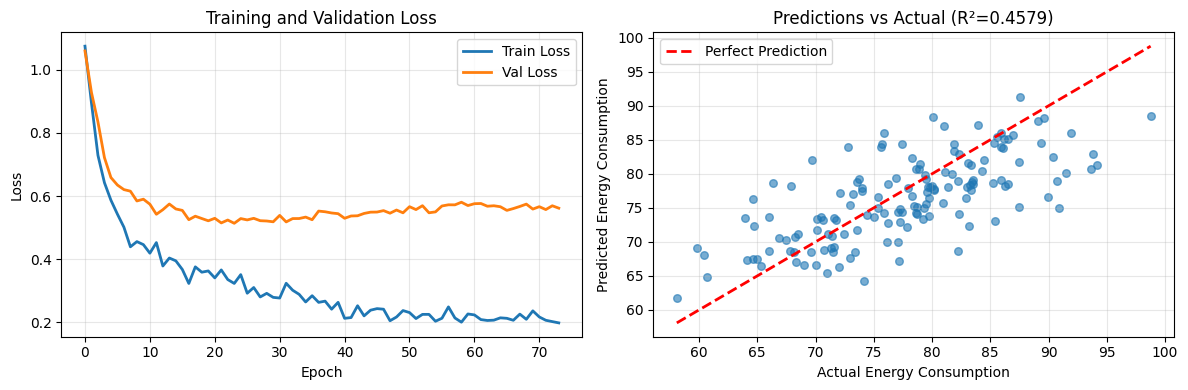


DONE


In [ ]:
print("\n" + "="*60)
print("EVALUATION")
print("="*60)
 
model.eval()
with torch.no_grad():
    test_predictions = model(X_test_tensor)
    test_loss = criterion(test_predictions, y_test_tensor).item()
 
print(f'Test Loss: {test_loss:.4f}')
 
y_test_pred = target_scaler.inverse_transform(test_predictions.detach().numpy())
y_test_true = target_scaler.inverse_transform(y_test_tensor.detach().numpy())
 
from sklearn.metrics import mean_absolute_error
 
mse = mean_squared_error(y_test_true, y_test_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_true, y_test_pred)
r2 = r2_score(y_test_true, y_test_pred)
 
print(f'Test MSE: {mse:.4f}')
print(f'Test RMSE: {rmse:.4f}')
print(f'Test MAE: {mae:.4f}')
print(f'Test R²: {r2:.4f}')
 
# Plot
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))
 
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', linewidth=2)
plt.plot(val_losses, label='Val Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
 
plt.subplot(1, 2, 2)
plt.scatter(y_test_true, y_test_pred, alpha=0.6, s=30)
plt.plot([y_test_true.min(), y_test_true.max()], 
         [y_test_true.min(), y_test_true.max()], 
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Energy Consumption')
plt.ylabel('Predicted Energy Consumption')
plt.title(f'Predictions vs Actual (R²={r2:.4f})')
plt.legend()
plt.grid(True, alpha=0.3)
 
plt.tight_layout()
plt.show()
 
print("\n" + "="*60)
print("TRAINING COMPLETE")
print("="*60)